# GRiD Theme 3 — YOLOv8 Training (Google Colab)

**Before you run anything:** set the runtime to GPU.
`Runtime > Change runtime type > Hardware accelerator > T4 GPU > Save`

Then run the cells top to bottom. At the end you download `best.pt` and drop it into your local `grid-traffic` folder.

Dataset: Helmet and Number Plate Detection for Motorbike Safety (iityz), version 3.

## 1. Confirm GPU is active

In [1]:
!nvidia-smi

Tue Jun 16 10:00:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install dependencies

In [2]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.3 MB/s eta 0:00:00


## 3. Download the dataset (re-download here, no big upload needed)
When prompted, paste your Roboflow API key (the same one from your `.env`). It is hidden as you type.

In [5]:
from getpass import getpass
from roboflow import Roboflow

api_key = getpass('Roboflow API key: ')
rf = Roboflow(api_key=api_key)
project = rf.workspace('helmet-and-number-plate-detection-project') \
            .project('helmet-and-number-plate-detection-for-motorbike-safety-iityz')
dataset = project.version(3).download('yolov8')
print('Dataset at:', dataset.location)

Roboflow API key: ··········
loading Roboflow workspace...
loading Roboflow project...
Dataset at: /content/Helmet-and-Number-Plate-Detection-for-Motorbike-Safety-3


## 4. Inspect class names (must match config.py CLASS_ALIASES)

In [6]:
import yaml, os
data_yaml = os.path.join(dataset.location, 'data.yaml')
with open(data_yaml) as f:
    d = yaml.safe_load(f)
print('Classes:', d.get('names'))
print('data.yaml path:', data_yaml)

Classes: ['bike', 'helmet', 'no-helmet', 'number-plate']
data.yaml path: /content/Helmet-and-Number-Plate-Detection-for-Motorbike-Safety-3/data.yaml


## 5. Train
Start with `yolov8n.pt` to confirm everything runs (~quick), then re-run with `yolov8s.pt` for the final model.
Bump `epochs` to 50 for the real run once the smoke test passes.

In [7]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')          # 'yolov8n.pt' for a faster first run
results = model.train(
    data=data_yaml,
    epochs=50,                       # 20-30 for smoke test, 50 for final
    imgsz=640,
    batch=16,
    patience=15,
    plots=True,
)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Helmet-and-Number-Plate-Detection-for-Motorbike-Safety-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, op

## 6. Validation metrics — copy these into your deck

In [8]:
m = model.val()
print(f'mAP@0.5      : {m.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {m.box.map:.4f}')
print(f'Precision    : {m.box.mp:.4f}')
print(f'Recall       : {m.box.mr:.4f}')

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1232.7±469.2 MB/s, size: 42.9 KB)
val: Scanning /content/Helmet-and-Number-Plate-Detection-for-Motorbike-Safety-3/valid/labels.cache... 1690 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1690/1690 545.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 41, len(boxes) = 8952. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 106/106 4.7it/s 22.6s
                   all       1690       8952      0.921      0.899       0.94      0.699
                  bike        977       2119      0.904      0.907      0.9

## 7. Eyeball a few predictions on validation images

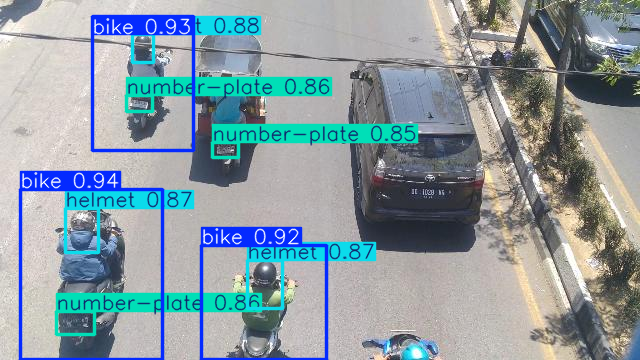

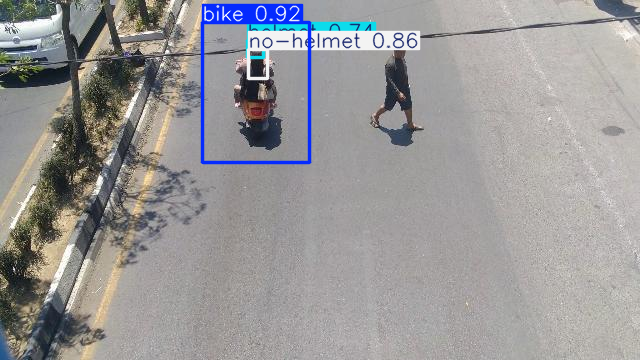

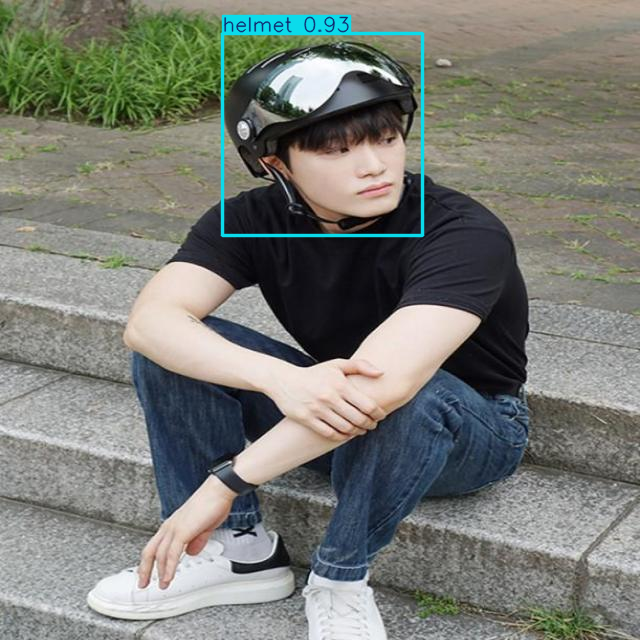

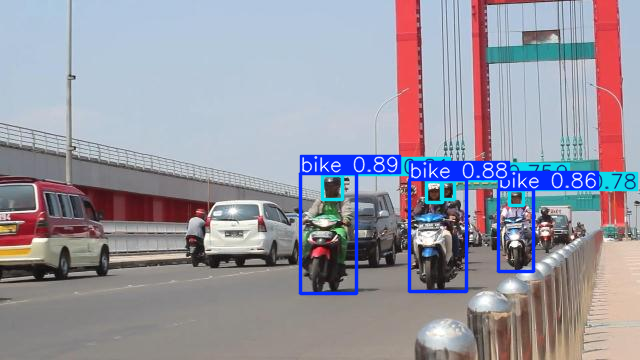

In [9]:
import glob
from PIL import Image
from IPython.display import display

val_imgs = glob.glob(os.path.join(dataset.location, 'valid', 'images', '*.jpg'))[:4]
for p in val_imgs:
    r = model(p, conf=0.35, verbose=False)[0]
    display(Image.fromarray(r.plot()[:, :, ::-1]))  # BGR->RGB

## 8. Download best.pt
Save this file into your local `D:\grid-traffic` folder, then set `MODEL_PATH = "best.pt"` in `config.py`.

In [10]:
from google.colab import files
best = 'runs/detect/train/weights/best.pt'
print('Downloading:', best)
files.download(best)

Downloading: runs/detect/train/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>